In [13]:
import importlib
import subprocess
import sys

required = {
    "pandas": "pandas",
    "numpy": "numpy",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
}

for module_name, package_name in required.items():
    try:
        importlib.import_module(module_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

In [71]:
# Load data
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('HR_data_2.csv')
df.head()

,Unnamed: 0,HR_TD_Mean,HR_TD_Median,HR_TD_std,HR_TD_Min,HR_TD_Max,HR_TD_AUC,HR_TD_Kurtosis,HR_TD_Skew,HR_TD_Slope_min,...,upset,hostile,alert,ashamed,inspired,nervous,attentive,afraid,active,determined
0,0,78.663878,76.70,7.480043,67.25,92.48,23048.450,-1.091448,0.369955,-0.7300,...,1.0,1.0,2.0,1.0,2.0,2.0,3.0,1.0,2.0,2.0
1,1,76.540732,76.61,2.584756,69.82,82.33,23959.920,-0.245338,0.338732,-0.3600,...,2.0,1.0,3.0,2.0,2.0,2.0,3.0,1.0,3.0,3.0
2,2,78.173563,77.92,2.681255,72.22,82.80,20324.605,-0.615922,-0.233047,-0.6300,...,1.0,1.0,2.0,1.0,3.0,2.0,3.0,2.0,3.0,3.0
3,3,83.073688,83.88,7.363598,69.42,96.12,24924.300,-0.866610,-0.046021,-0.4650,...,1.0,1.0,2.0,1.0,3.0,2.0,3.0,2.0,3.0,3.0
4,4,72.281250,72.91,3.193762,64.95,79.98,23052.100,0.200401,-0.560948,-0.3725,...,3.0,1.0,3.0,2.0,3.0,3.0,4.0,2.0,4.0,4.0


In [72]:
# Drop first column (index-like column)
first_col = df.columns[0]
df = df.drop(columns=first_col)

print(f"\nDropped first column: {first_col}")
print(f"Columns after drop ({len(df.columns)}):")
for i, col in enumerate(df.columns, start=1):
    print(f"{i:>3}. {col}")

# Keep columns up to and including Team_ID, but keep Cohort as an exception if it exists.
cutoff_col = "Team_ID"
exception_col = "Cohort"

if cutoff_col not in df.columns:
    raise ValueError(f"Column '{cutoff_col}' not found in df.")

cutoff_idx = df.columns.get_loc(cutoff_col)
base_kept = list(df.columns[:cutoff_idx + 1])

# Preserve Cohort even if it appears after Team_ID.
if exception_col in df.columns and exception_col not in base_kept:
    kept_cols = base_kept + [exception_col]
else:
    kept_cols = base_kept

removed_cols = [c for c in df.columns if c not in kept_cols]

df = df.loc[:, kept_cols].copy()

print(f"Kept columns (through {cutoff_col} + optional {exception_col}): {len(kept_cols)}")
print(f"Dropped columns: {len(removed_cols)}")

if exception_col in df.columns:
    print(f"Kept exception column: {exception_col}")

if removed_cols:
    print("Dropped:")
    for c in removed_cols:
        print(f"- {c}")

# print full column/feature list
print("\nFinal columns in df:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i:>3}. {col}")

# also what unique cohort vlaues do I have?
if "Cohort" in df.columns:
    unique_cohorts = df["Cohort"].unique()
    print(f"\nUnique Cohort values ({len(unique_cohorts)}): {unique_cohorts}")
else:   print("\nNo Cohort column found in df.")


Dropped first column: Unnamed: 0
Columns after drop (70):
  1. HR_TD_Mean
  2. HR_TD_Median
  3. HR_TD_std
  4. HR_TD_Min
  5. HR_TD_Max
  6. HR_TD_AUC
  7. HR_TD_Kurtosis
  8. HR_TD_Skew
  9. HR_TD_Slope_min
 10. HR_TD_Slope_max
 11. HR_TD_Slope_mean
 12. HR_TD_Slope
 13. TEMP_TD_Mean
 14. TEMP_TD_Median
 15. TEMP_TD_std
 16. TEMP_TD_Min
 17. TEMP_TD_Max
 18. TEMP_TD_AUC
 19. TEMP_TD_Kurtosis
 20. TEMP_TD_Skew
 21. TEMP_TD_Slope_min
 22. TEMP_TD_Slope_max
 23. TEMP_TD_Slope_mean
 24. TEMP_TD_Slope
 25. EDA_TD_P_Mean
 26. EDA_TD_P_Median
 27. EDA_TD_P_std
 28. EDA_TD_P_Min
 29. EDA_TD_P_Max
 30. EDA_TD_P_AUC
 31. EDA_TD_P_Kurtosis
 32. EDA_TD_P_Skew
 33. EDA_TD_P_Slope_min
 34. EDA_TD_P_Slope_max
 35. EDA_TD_P_Slope_mean
 36. EDA_TD_P_Slope
 37. EDA_TD_T_Mean
 38. EDA_TD_T_Median
 39. EDA_TD_T_std
 40. EDA_TD_T_Min
 41. EDA_TD_T_Max
 42. EDA_TD_T_AUC
 43. EDA_TD_T_Kurtosis
 44. EDA_TD_T_Skew
 45. EDA_TD_T_Slope_min
 46. EDA_TD_T_Slope_max
 47. EDA_TD_T_Slope_mean
 48. EDA_TD_T_Slope
 

In [73]:
# Also drop original_ID and raw_data_path if present
drop_cols = ["original_ID", "raw_data_path"]
existing_drop_cols = [c for c in drop_cols if c in df.columns]
missing_drop_cols = [c for c in drop_cols if c not in df.columns]

if existing_drop_cols:
    df = df.drop(columns=existing_drop_cols)
    print(f"Dropped columns: {existing_drop_cols}")
else:
    print("No target columns to drop.")

if missing_drop_cols:
    print(f"Already missing (not dropped): {missing_drop_cols}")

print(f"Remaining columns: {len(df.columns)}")

Dropped columns: ['original_ID', 'raw_data_path']
Remaining columns: 57


In [79]:
df.head

<bound method NDFrame.head of      HR_TD_Mean  HR_TD_Median  HR_TD_std  HR_TD_Min  HR_TD_Max  HR_TD_AUC  \
11    81.802706        77.350  11.111633      69.67     108.35  24707.120   
10    73.961289        71.530   5.500071      67.37      87.83  23448.860   
9     77.879577        78.750   5.713568      65.73      85.98  23835.070   
5     85.377261        82.820  12.030816      73.75     132.63  25763.440   
4     72.281250        72.910   3.193762      64.95      79.98  23052.100   
..          ...           ...        ...        ...        ...        ...   
301  108.283258       106.630  11.525887      89.17     126.08  33457.385   
300  110.892894       103.220  12.805686      91.25     134.72  34392.740   
308  103.274248       104.625  14.208117      68.13     125.52  31523.695   
307   82.019065        78.830   8.794206      69.73      97.18  26244.705   
306   90.507949        90.370   3.230269      85.37      96.45  28145.865   

     HR_TD_Kurtosis  HR_TD_Skew  HR_TD_Slope_

Your Execution Checklist

    [x] Scale data per subject.

    [x] Visualize 1-2 individuals to confirm a visible stress jump.

    [ ] Run PCA and check the Scree Plot.

    [ ] Color-code the 2D results by Phase, Role, and Time.

    [ ] Run SPCA to extract the "Most Important" features for your final argument.

# first look at the data

In [110]:
# Look at Puzzler and Phase unique values sorted by round and phase
for column_name in ["Puzzler", "Phase"]:
    if column_name in df.columns:
        unique_values = df[column_name].dropna().unique()
        print(f"{column_name} unique values ({len(unique_values)}): {unique_values}")
    else:
        print(f"No {column_name} column found in df.")

# Show the full row data for Individual 1
if "Individual" in df.columns:
    individual_1_data = df[df["Individual"] == 1]
    individual_1_data = individual_1_data.sort_values(by=["Round", "Phase"])
    print(f"\nRows for Individual 1: {len(individual_1_data)}")
    print(individual_1_data.to_string(index=False))
else:
    print("No Individual column found in df.")


# Show the full row data for Individual 2 sorted by round and phase

if "Individual" in df.columns:
    individual_2_data = df[df["Individual"] == 2]
    individual_2_data = individual_2_data.sort_values(by=["Round", "Phase"])
    print(f"\nRows for Individual 2: {len(individual_2_data)}")
    print(individual_2_data.to_string(index=False))
else:
    print("No Individual column found in df.")

Puzzler unique values (2): [1 0]
Phase unique values (3): <StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Rows for Individual 1: 12
 HR_TD_Mean  HR_TD_Median  HR_TD_std  HR_TD_Min  HR_TD_Max  HR_TD_AUC  HR_TD_Kurtosis  HR_TD_Skew  HR_TD_Slope_min  HR_TD_Slope_max  HR_TD_Slope_mean  HR_TD_Slope  TEMP_TD_Mean  TEMP_TD_Median  TEMP_TD_std  TEMP_TD_Min  TEMP_TD_Max  TEMP_TD_AUC  TEMP_TD_Kurtosis  TEMP_TD_Skew  TEMP_TD_Slope_min  TEMP_TD_Slope_max  TEMP_TD_Slope_mean  TEMP_TD_Slope  EDA_TD_P_Mean  EDA_TD_P_Median  EDA_TD_P_std  EDA_TD_P_Min  EDA_TD_P_Max  EDA_TD_P_AUC  EDA_TD_P_Kurtosis  EDA_TD_P_Skew  EDA_TD_P_Slope_min  EDA_TD_P_Slope_max  EDA_TD_P_Slope_mean  EDA_TD_P_Slope  EDA_TD_T_Mean  EDA_TD_T_Median  EDA_TD_T_std  EDA_TD_T_Min  EDA_TD_T_Max  EDA_TD_T_AUC  EDA_TD_T_Kurtosis  EDA_TD_T_Skew  EDA_TD_T_Slope_min  EDA_TD_T_Slope_max  EDA_TD_T_Slope_mean  EDA_TD_T_Slope  EDA_TD_P_Peaks  EDA_TD_P_RT  EDA_TD_P_ReT   Round  Phase  Individual  Puzzler     Team_ID Cohort  T

# look at two individuals median values (puzzler and instructor)
## individuals 

1. look at the data for one individual only -> check round etc. full view
2. compare puzzler vs instructor
time -> done
try to see the features for the phases 1,2,3 -> do they shift? can we clearly separate rest from stress?


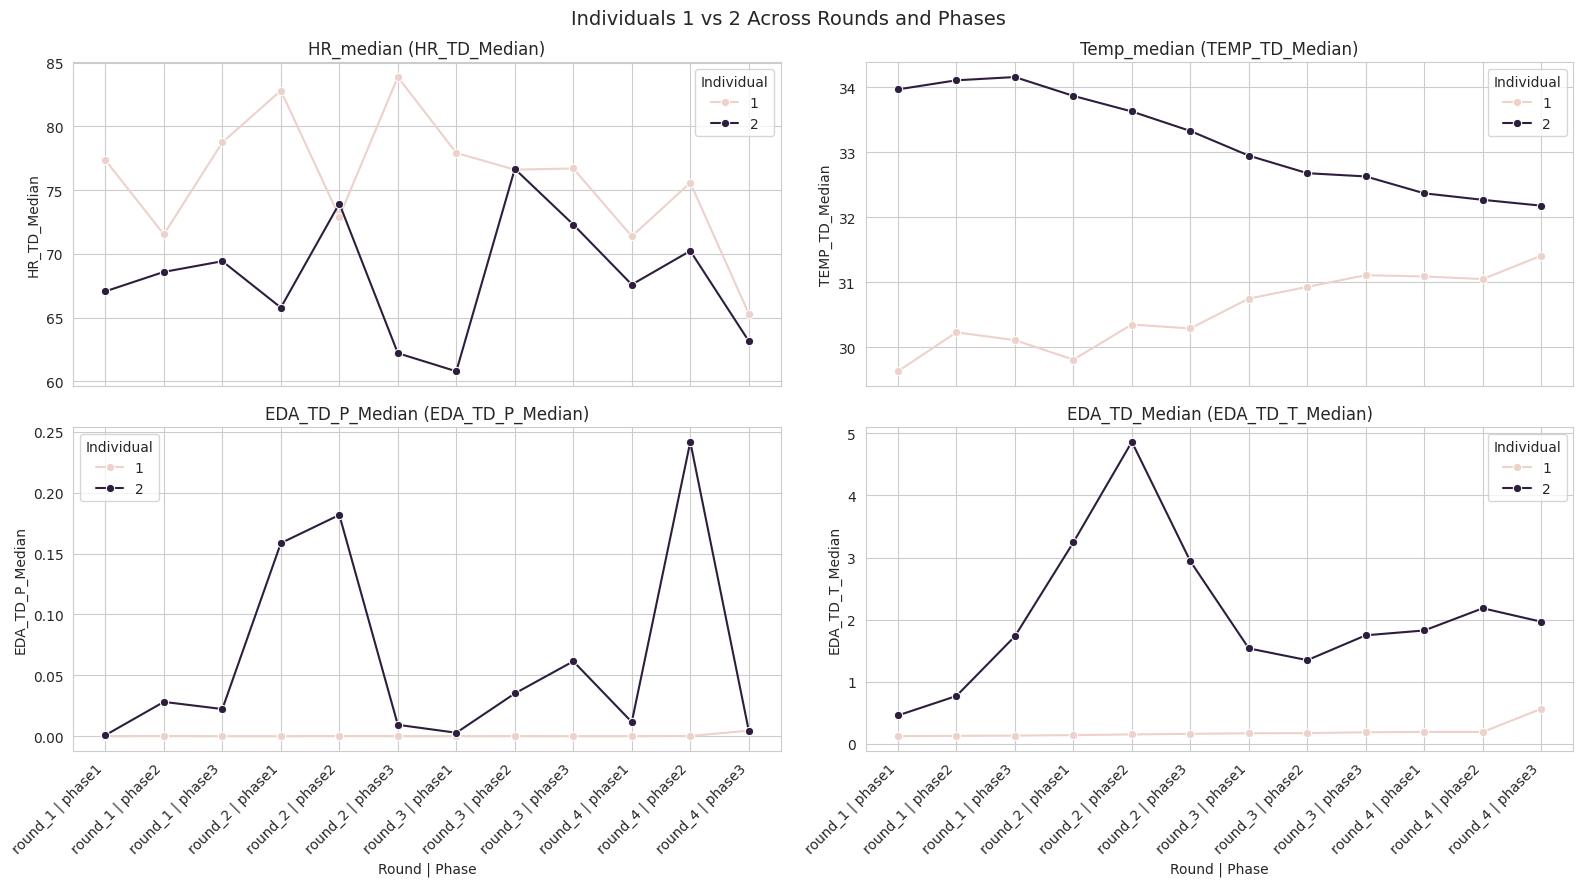

In [55]:
# Simple comparison plot for Individuals 1 and 2 across rounds/phases
import re
import matplotlib.pyplot as plt
import seaborn as sns

# Requested features (with robust fallback names)
requested_features = {
    "HR_median": ["HR_median", "HR_TD_Median"],
    "Temp_median": ["Temp_median", "TEMP_TD_Median", "Temp_TD_Median"],
    "EDA_TD_P_Median": ["EDA_TD_P_Median"],
    "EDA_TD_Median": ["EDA_TD_Median", "EDA_TD_T_Median"],
}

if "Individual" not in df.columns or "Round" not in df.columns or "Phase" not in df.columns:
    raise ValueError("Columns 'Individual', 'Round', and 'Phase' are required for this plot.")

# Pick whichever matching column exists in df for each requested signal.
feature_map = {}
missing = []
for label, candidates in requested_features.items():
    match = next((c for c in candidates if c in df.columns), None)
    if match is None:
        missing.append(label)
    else:
        feature_map[label] = match

if not feature_map:
    raise ValueError("None of the requested features were found in df.")

if missing:
    print(f"Missing requested features (skipped): {missing}")

plot_df = df[df["Individual"].isin([1, 2])].copy()
if plot_df.empty:
    raise ValueError("No rows found for Individuals 1 and 2.")

# Extract numeric order from strings like round_3 / phase2 for correct timeline sorting.
plot_df["Round_num"] = plot_df["Round"].astype(str).str.extract(r"(\d+)").astype(float)
plot_df["Phase_num"] = plot_df["Phase"].astype(str).str.extract(r"(\d+)").astype(float)

plot_df = plot_df.sort_values(["Round_num", "Phase_num", "Individual"])
plot_df["Round_Phase"] = plot_df["Round"].astype(str) + " | " + plot_df["Phase"].astype(str)

# Build stable x-order from sorted numeric round/phase pairs.
x_order = (
    plot_df[["Round_num", "Phase_num", "Round_Phase"]]
    .drop_duplicates()
    .sort_values(["Round_num", "Phase_num"])["Round_Phase"]
    .tolist()
)

sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex=True)
axes = axes.flatten()

for ax, (label, col_name) in zip(axes, feature_map.items()):
    sns.lineplot(
        data=plot_df,
        x="Round_Phase",
        y=col_name,
        hue="Individual",
        marker="o",
        hue_order=[1, 2],
        estimator=None,
        sort=False,
        ax=ax,
    )
    ax.set_title(f"{label} ({col_name})")
    ax.set_xlabel("Round | Phase")
    ax.set_ylabel(col_name)
    ax.set_xticks(range(len(x_order)))
    ax.set_xticklabels(x_order, rotation=45, ha="right")
    ax.legend(title="Individual")

# Hide unused subplot(s) if fewer than 4 features were found.
for ax in axes[len(feature_map):]:
    ax.set_visible(False)

plt.suptitle("Individuals 1 vs 2 Across Rounds and Phases", fontsize=14)
plt.tight_layout()
plt.show()

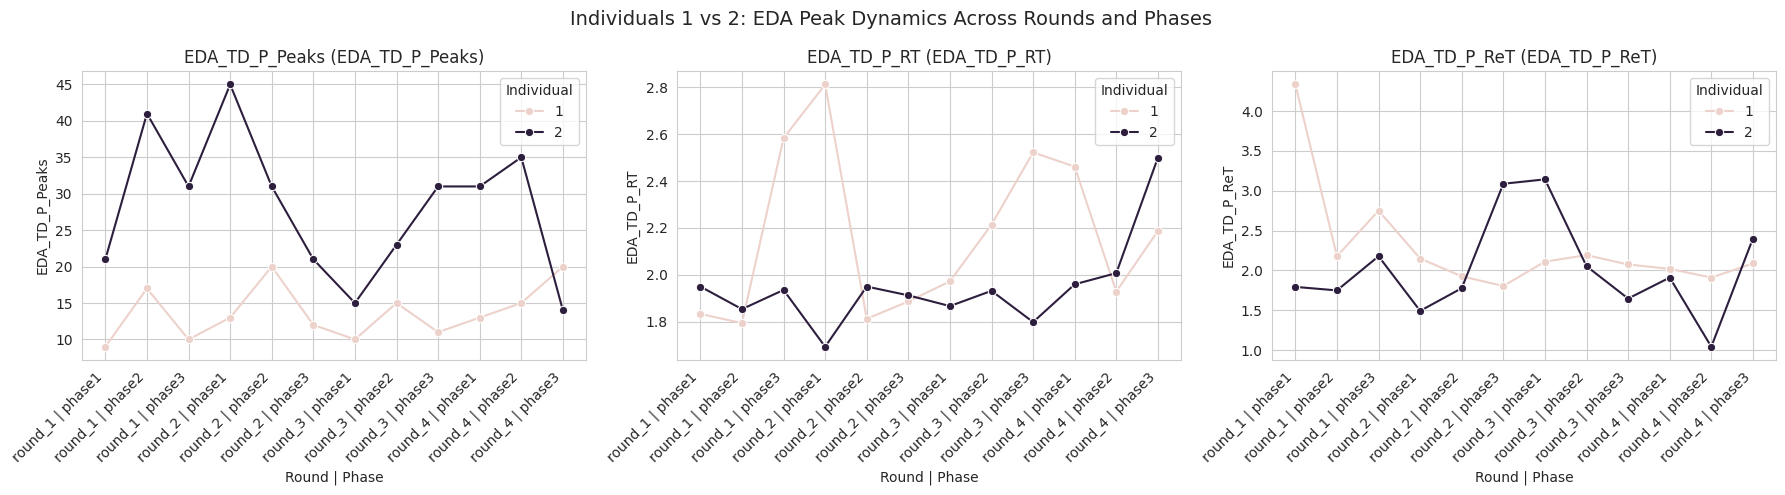

In [56]:
# Additional comparison plot for EDA dynamics features (Individuals 1 and 2)
import matplotlib.pyplot as plt
import seaborn as sns

eda_dynamic_features = {
    "EDA_TD_P_Peaks": ["EDA_TD_P_Peaks"],
    "EDA_TD_P_RT": ["EDA_TD_P_RT"],
    "EDA_TD_P_ReT": ["EDA_TD_P_ReT"],
}

if "Individual" not in df.columns or "Round" not in df.columns or "Phase" not in df.columns:
    raise ValueError("Columns 'Individual', 'Round', and 'Phase' are required for this plot.")

feature_map_eda = {}
missing_eda = []
for label, candidates in eda_dynamic_features.items():
    match = next((c for c in candidates if c in df.columns), None)
    if match is None:
        missing_eda.append(label)
    else:
        feature_map_eda[label] = match

if not feature_map_eda:
    raise ValueError("None of the requested EDA dynamic features were found in df.")

if missing_eda:
    print(f"Missing requested EDA features (skipped): {missing_eda}")

plot_df_eda = df[df["Individual"].isin([1, 2])].copy()
if plot_df_eda.empty:
    raise ValueError("No rows found for Individuals 1 and 2.")

plot_df_eda["Round_num"] = plot_df_eda["Round"].astype(str).str.extract(r"(\d+)").astype(float)
plot_df_eda["Phase_num"] = plot_df_eda["Phase"].astype(str).str.extract(r"(\d+)").astype(float)
plot_df_eda = plot_df_eda.sort_values(["Round_num", "Phase_num", "Individual"])
plot_df_eda["Round_Phase"] = plot_df_eda["Round"].astype(str) + " | " + plot_df_eda["Phase"].astype(str)

x_order_eda = (
    plot_df_eda[["Round_num", "Phase_num", "Round_Phase"]]
    .drop_duplicates()
    .sort_values(["Round_num", "Phase_num"])["Round_Phase"]
    .tolist()
)

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

for ax, (label, col_name) in zip(axes, feature_map_eda.items()):
    sns.lineplot(
        data=plot_df_eda,
        x="Round_Phase",
        y=col_name,
        hue="Individual",
        marker="o",
        hue_order=[1, 2],
        estimator=None,
        sort=False,
        ax=ax,
    )
    ax.set_title(f"{label} ({col_name})")
    ax.set_xlabel("Round | Phase")
    ax.set_ylabel(col_name)
    ax.set_xticks(range(len(x_order_eda)))
    ax.set_xticklabels(x_order_eda, rotation=45, ha="right")
    ax.legend(title="Individual")

plt.suptitle("Individuals 1 vs 2: EDA Peak Dynamics Across Rounds and Phases", fontsize=14)
plt.tight_layout()
plt.show()

# preliminary data quality check
- missing values -> print rows 
- decide imputation (median like albert?) -> yes
- individual z score scaling
- hierarchical correlation matrix of features



## extra

we could also check round 1 vs round 4 values of the same person -> hanlded by the time index feature we add

Per-Subject Scaling, Z-score normalization individually

Why: 
removes the "Person Baseline" (e.g., some people naturally sweat more) 

Scaling within the individual ensures that the "Decreasing HR" person and the "Increasing HR" person are both seen as "reacting" relative to their own baseline
-> see individual comparison charts

In [103]:
# Inter-subject scaling for PCA prep (with Time_Index + NaN handling included)
# Strategy:
# 1) Create within-person Time_Index.
# 2) Detect and print missing rows.
# 3) Impute EDA_TD_P_RT / EDA_TD_P_ReT on df.
# 4) Build meta_df + numeric_df.
# 5) Scale physiological features within each Individual.
# 6) Scale Puzzler and Time_Index globally.
# 7) Fill any remaining NaNs with 0 and verify mean/std ~ 0/1.

# ----- Build Time_Index first -----
required_cols = ["Individual", "Round", "Phase"]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# Parse numeric order from labels like round_1 / phase1.
df["Round_num"] = (
    df["Round"]
    .astype(str)
    .str.extract(r"(\d+)", expand=False)
    .astype(float)
)
df["Phase_num"] = (
    df["Phase"]
    .astype(str)
    .str.extract(r"(\d+)", expand=False)
    .astype(float)
)

if df[["Round_num", "Phase_num"]].isna().any().any():
    bad_rows = df[df[["Round_num", "Phase_num"]].isna().any(axis=1)][["Individual", "Round", "Phase"]]
    raise ValueError(
        "Could not parse Round/Phase order for some rows. Please check labels.\n"
        f"Examples:\n{bad_rows.head(10).to_string(index=False)}"
    )

# Sort within each person and assign index 1..N (expected N=12)
df = df.sort_values(["Individual", "Round_num", "Phase_num"]).copy()
df["Time_Index"] = df.groupby("Individual").cumcount() + 1

# Keep df clean by dropping helper columns used for ordering
df = df.drop(columns=["Round_num", "Phase_num"])

# Quick checks
counts = df.groupby("Individual")["Time_Index"].max()
print("Max Time_Index per individual (should usually be 12):")
print(counts.head(10).to_string())

print("\nAny individual not ending at 12?")
not_12 = counts[counts != 12]
if not_12.empty:
    print("No, all individuals end at Time_Index = 12.")
else:
    print(not_12.to_string())

print("\nPreview:")
print(df[["Individual", "Round", "Phase", "Time_Index"]].head(20).to_string(index=False))

# ----- Missing-value handling on df -----
missing_rows = df[df.isnull().any(axis=1)]
print(f"\nRows with missing values: {len(missing_rows)}")
if not missing_rows.empty:
    print(missing_rows.to_string(index=False))

for col in ["EDA_TD_P_RT", "EDA_TD_P_ReT"]:
    if col in df.columns:
        imputer = SimpleImputer(strategy="median")
        df[col] = imputer.fit_transform(df[[col]])

if "Individual" in df.columns and "Round" in df.columns and "Phase" in df.columns:
    row_23_4_1 = df[
        (df["Individual"] == 23) &
        (df["Round"] == "round_4") &
        (df["Phase"] == "phase1")
    ]
    print("\nRow for Individual 23, Round 4, Phase 1 after imputation:")
    print(row_23_4_1.to_string(index=False))

# ----- Build metadata/numeric matrices after imputation -----
required_meta_cols = ["Individual", "Round", "Phase", "Team_ID", "Cohort"]
missing_meta_cols = [c for c in required_meta_cols if c not in df.columns]
if missing_meta_cols:
    raise ValueError(f"Missing metadata columns in df: {missing_meta_cols}")

meta_df = df[required_meta_cols].copy()
numeric_cols = [c for c in df.columns if c not in meta_df.columns]
numeric_df = df[numeric_cols].copy()

if not numeric_df.index.equals(meta_df.index):
    raise ValueError("numeric_df and meta_df index do not match. Rebuild numeric_df/meta_df first.")

# ----- Scaling setup -----
global_scale_cols = [c for c in ["Puzzler", "Time_Index"] if c in numeric_df.columns]
physio_cols = [c for c in numeric_df.columns if c not in global_scale_cols]

if not physio_cols:
    raise ValueError("No physiological columns found to scale.")

scaled_numeric_df = numeric_df.copy()

# NaN count before scaling (includes any pre-existing missing values).
nan_before_scaling = int(scaled_numeric_df.isna().sum().sum())

# Capture exact NaN locations before scaling.
nans_before_df = (
    scaled_numeric_df.isna()
    .stack()
    .loc[lambda s: s]
    .reset_index()
    .rename(columns={"level_0": "row_index", "level_1": "column", 0: "is_nan"})
)

# Per-individual Z-scaling for physiological signals.
def zscore_group(g):
    return (g - g.mean()) / g.std(ddof=0)

scaled_numeric_df[physio_cols] = (
    scaled_numeric_df[physio_cols]
    .groupby(meta_df["Individual"])
    .transform(zscore_group)
)

# Global scaling for Puzzler and Time_Index.
if global_scale_cols:
    global_scaler = StandardScaler()
    scaled_numeric_df[global_scale_cols] = global_scaler.fit_transform(scaled_numeric_df[global_scale_cols])

nan_after_scaling = int(scaled_numeric_df.isna().sum().sum())

# Capture exact NaN locations after scaling (and before fill).
nans_after_scaling_df = (
    scaled_numeric_df.isna()
    .stack()
    .loc[lambda s: s]
    .reset_index()
    .rename(columns={"level_0": "row_index", "level_1": "column", 0: "is_nan"})
)

# Final NaN cleanup for flat-liners.
scaled_numeric_df = scaled_numeric_df.fillna(0)

nan_after_fill = int(scaled_numeric_df.isna().sum().sum())
nan_created_by_scaling = max(nan_after_scaling - nan_before_scaling, 0)
nan_filled = nan_after_scaling - nan_after_fill

# Final PCA input matrix.
pca_input_df = scaled_numeric_df.copy()

# Final pre-PCA checks.
summary = pd.DataFrame({
    "mean": pca_input_df.mean(),
    "std": pca_input_df.std(ddof=0),
    "var": pca_input_df.var(ddof=0),
})

print(f"\nPCA input dataframe shape (rows, columns): {pca_input_df.shape}")
print("\nNaN diagnostics:")
print(f"NaNs before scaling: {nan_before_scaling}")
print(f"NaNs after scaling: {nan_after_scaling}")
print(f"NaNs created by scaling: {nan_created_by_scaling}")
print(f"NaNs filled with 0: {nan_filled}")
print(f"NaNs after fill: {nan_after_fill}")

print("\nNaN locations before scaling:")
if nans_before_df.empty:
    print("None")
else:
    print(nans_before_df[["row_index", "column"]].to_string(index=False))

print("\nNaN locations after scaling (before fill):")
if nans_after_scaling_df.empty:
    print("None")
else:
    print(nans_after_scaling_df[["row_index", "column"]].to_string(index=False))

print("\nColumn-level check (first 15 columns):")
print(summary.head(15).to_string())

print("\nGlobal check across columns:")
print(f"Average |mean| across columns: {summary['mean'].abs().mean():.4f}")
print(f"Average std across columns: {summary['std'].mean():.4f}")

for col in ["Puzzler", "Time_Index"]:
    if col in pca_input_df.columns:
        print(f"Variance of {col} after scaling: {summary.loc[col, 'var']:.4f}")
    else:
        print(f"Column {col} not present in numeric_df (skipped variance check).")

Max Time_Index per individual (should usually be 12):
Individual
1     12
2     12
3     12
4     12
5     12
6     12
7     12
8     12
9     12
10    12

Any individual not ending at 12?
No, all individuals end at Time_Index = 12.

Preview:
 Individual   Round  Phase  Time_Index
          1 round_1 phase1           1
          1 round_1 phase2           2
          1 round_1 phase3           3
          1 round_2 phase1           4
          1 round_2 phase2           5
          1 round_2 phase3           6
          1 round_3 phase1           7
          1 round_3 phase2           8
          1 round_3 phase3           9
          1 round_4 phase1          10
          1 round_4 phase2          11
          1 round_4 phase3          12
          2 round_1 phase1           1
          2 round_1 phase2           2
          2 round_1 phase3           3
          2 round_2 phase1           4
          2 round_2 phase2           5
          2 round_2 phase3           6
          2 roun

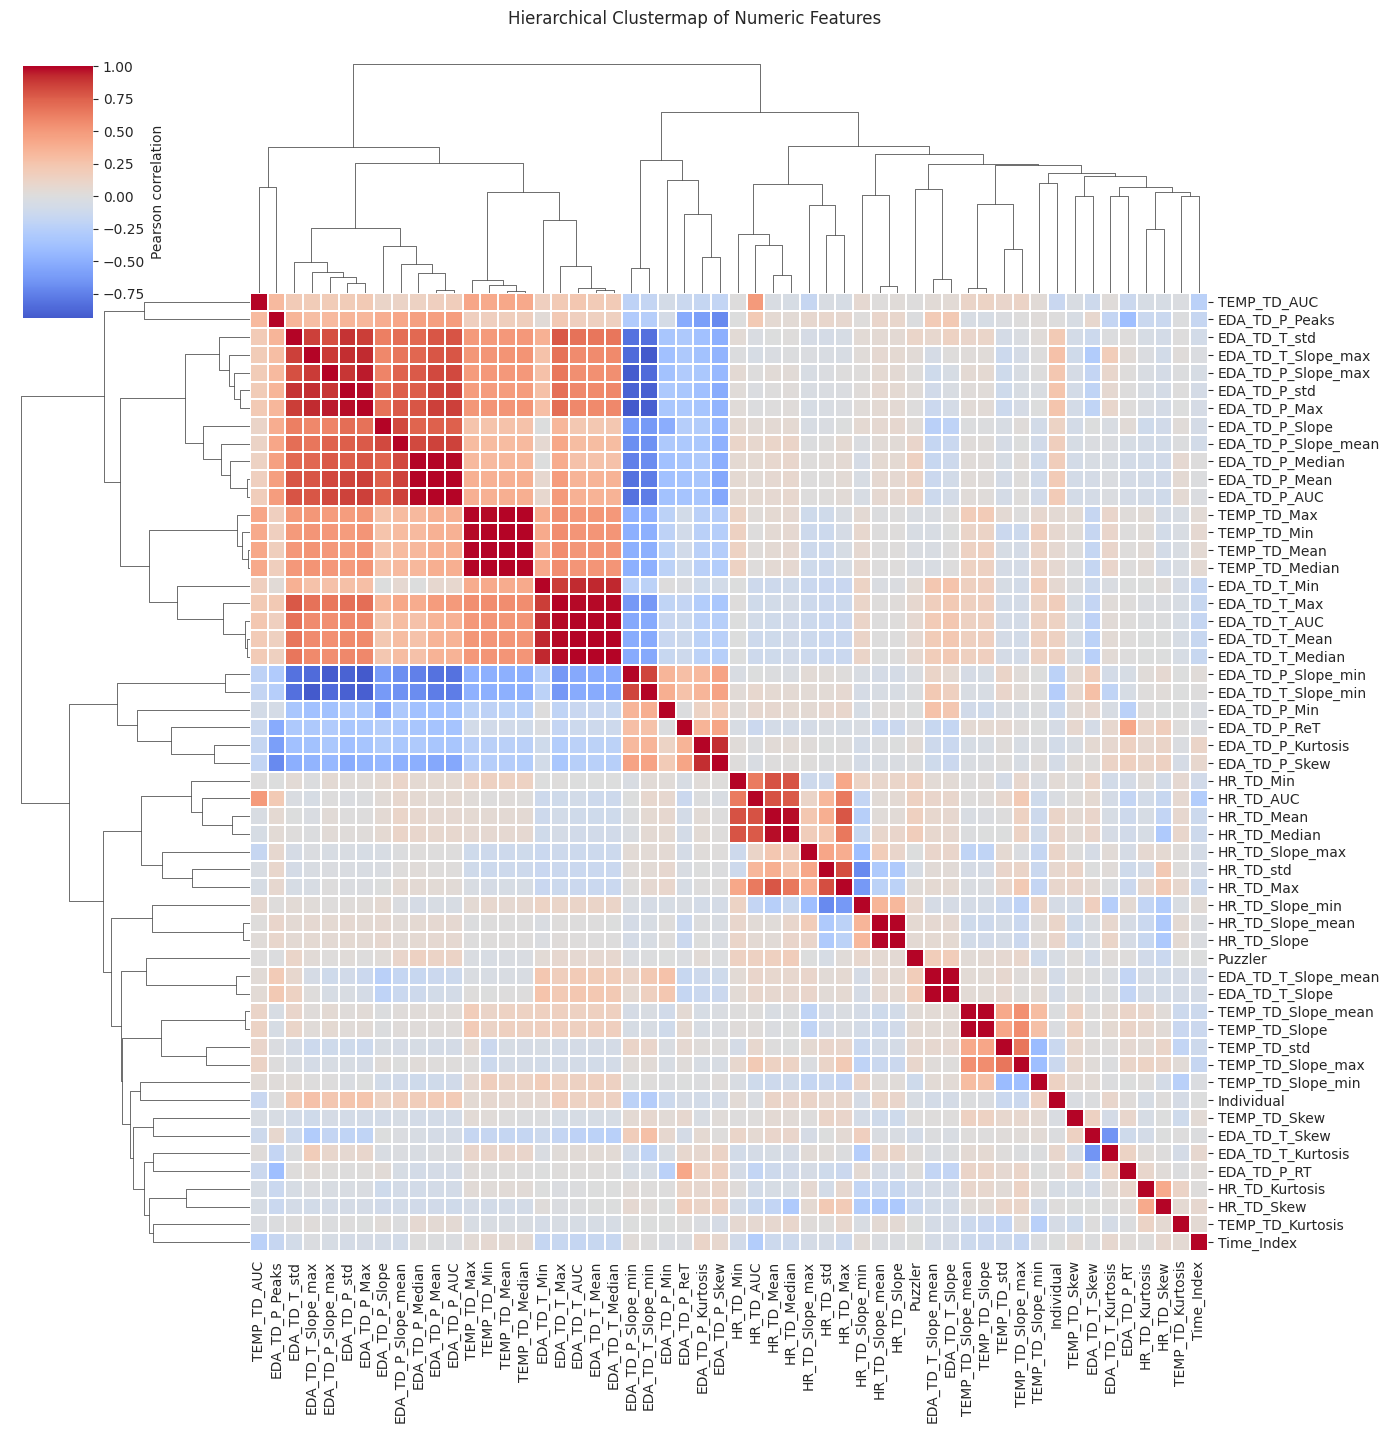

In [100]:
# correlation clustermap of all numeric features
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = df.select_dtypes(include=np.number)
if numeric_df.empty:
    print("No numeric features found for correlation clustermap.")
else:
    corr = numeric_df.corr()
    sns.clustermap(
        corr,
        cmap="coolwarm",
        center=0,
        linewidths=0.2,
        figsize=(14, 14),
        cbar_kws={"label": "Pearson correlation"},
    )
    plt.suptitle("Hierarchical Clustermap of Numeric Features", y=1.02)
    plt.show()

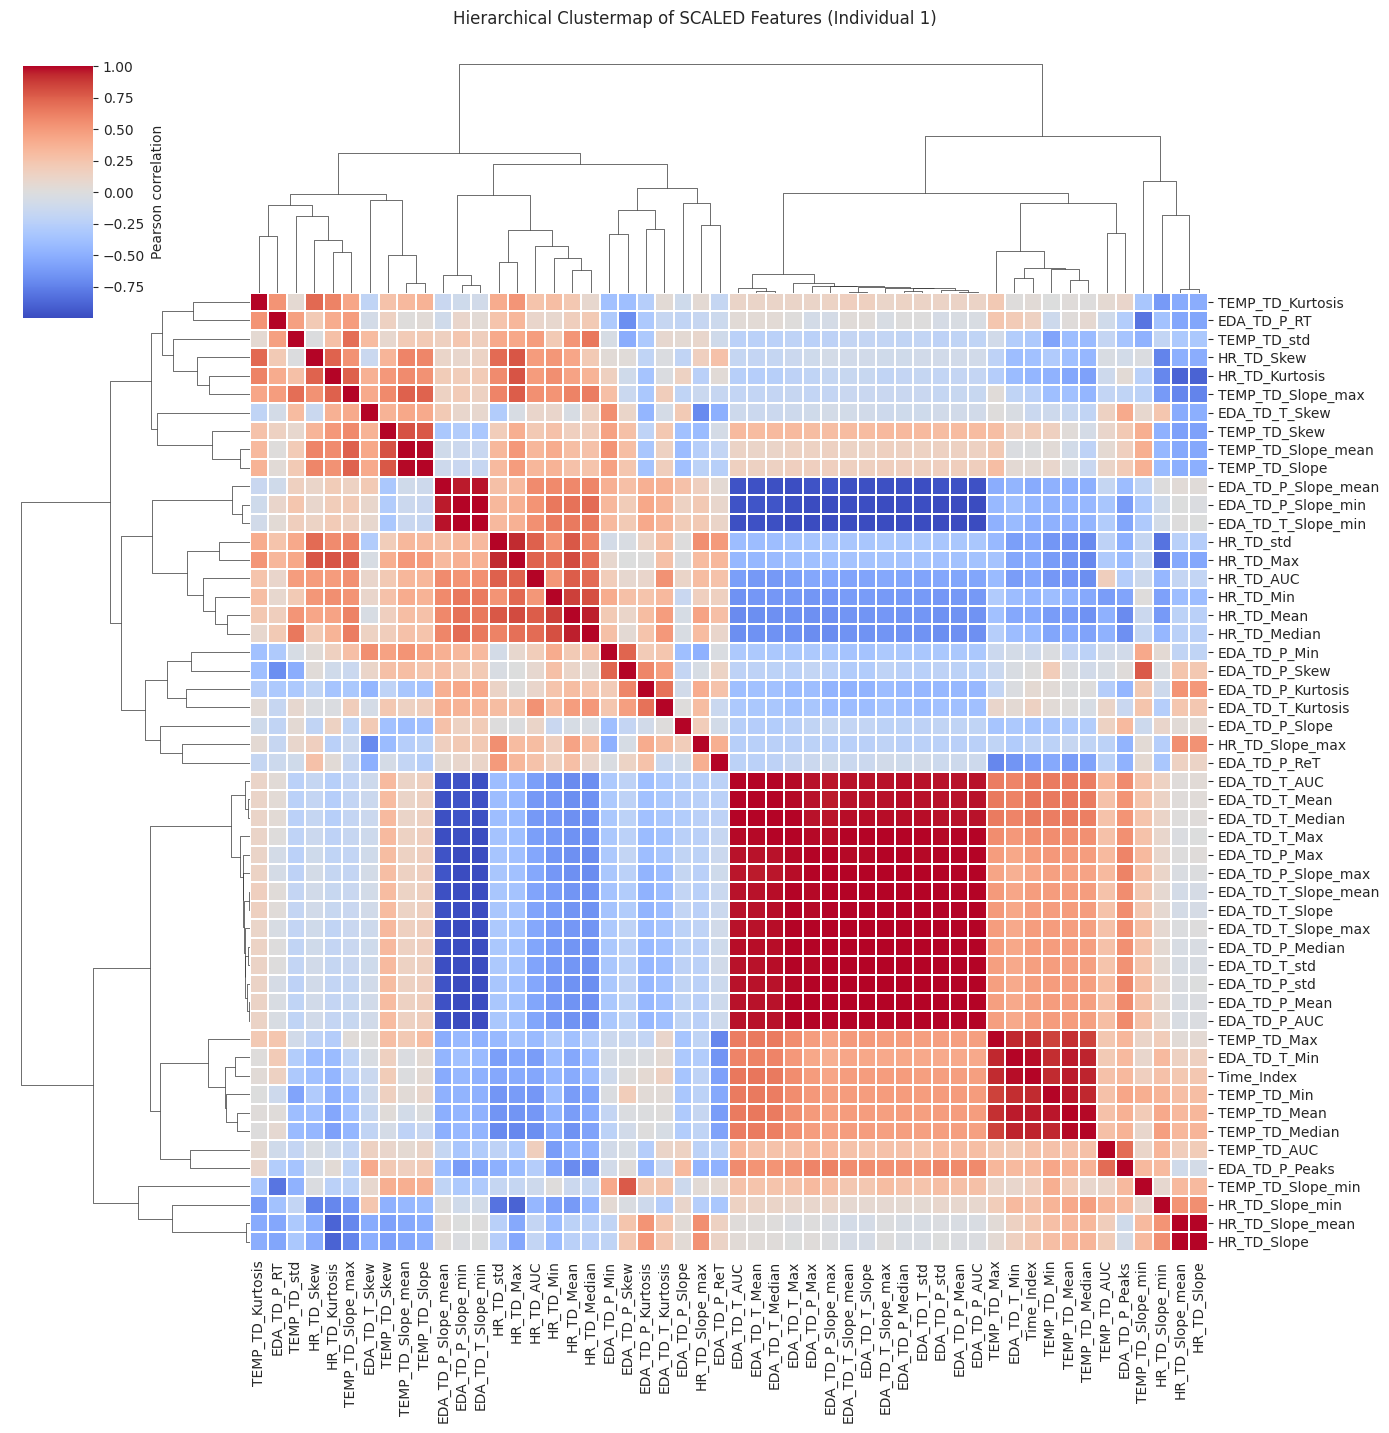

In [104]:
# Correlation clustermap for one individual using SCALED data
import matplotlib.pyplot as plt
import seaborn as sns

individual_id = 1  # change this to any person you want to inspect

if "pca_input_df" not in globals() or "meta_df" not in globals():
    raise ValueError("Run the preprocessing/scaling cell first so pca_input_df and meta_df exist.")

if "Individual" not in meta_df.columns:
    raise ValueError("meta_df must contain the 'Individual' column.")

if not pca_input_df.index.equals(meta_df.index):
    raise ValueError("pca_input_df and meta_df indices do not match. Re-run preprocessing cell.")

# Filter scaled rows for one individual.
ind_mask = meta_df["Individual"] == individual_id
numeric_ind_df = pca_input_df.loc[ind_mask].copy()

if numeric_ind_df.empty:
    raise ValueError(f"No rows found for Individual={individual_id}.")

# Drop constant columns (std=0) for stable correlations.
non_constant_cols = numeric_ind_df.columns[numeric_ind_df.std(ddof=0) > 0]
numeric_ind_df = numeric_ind_df[non_constant_cols]

if numeric_ind_df.shape[1] < 2:
    print("Not enough varying scaled features to compute a correlation clustermap.")
else:
    corr = numeric_ind_df.corr()
    sns.clustermap(
        corr,
        cmap="coolwarm",
        center=0,
        linewidths=0.2,
        figsize=(14, 14),
        cbar_kws={"label": "Pearson correlation"},
    )
    plt.suptitle(f"Hierarchical Clustermap of SCALED Features (Individual {individual_id})", y=1.02)
    plt.show()

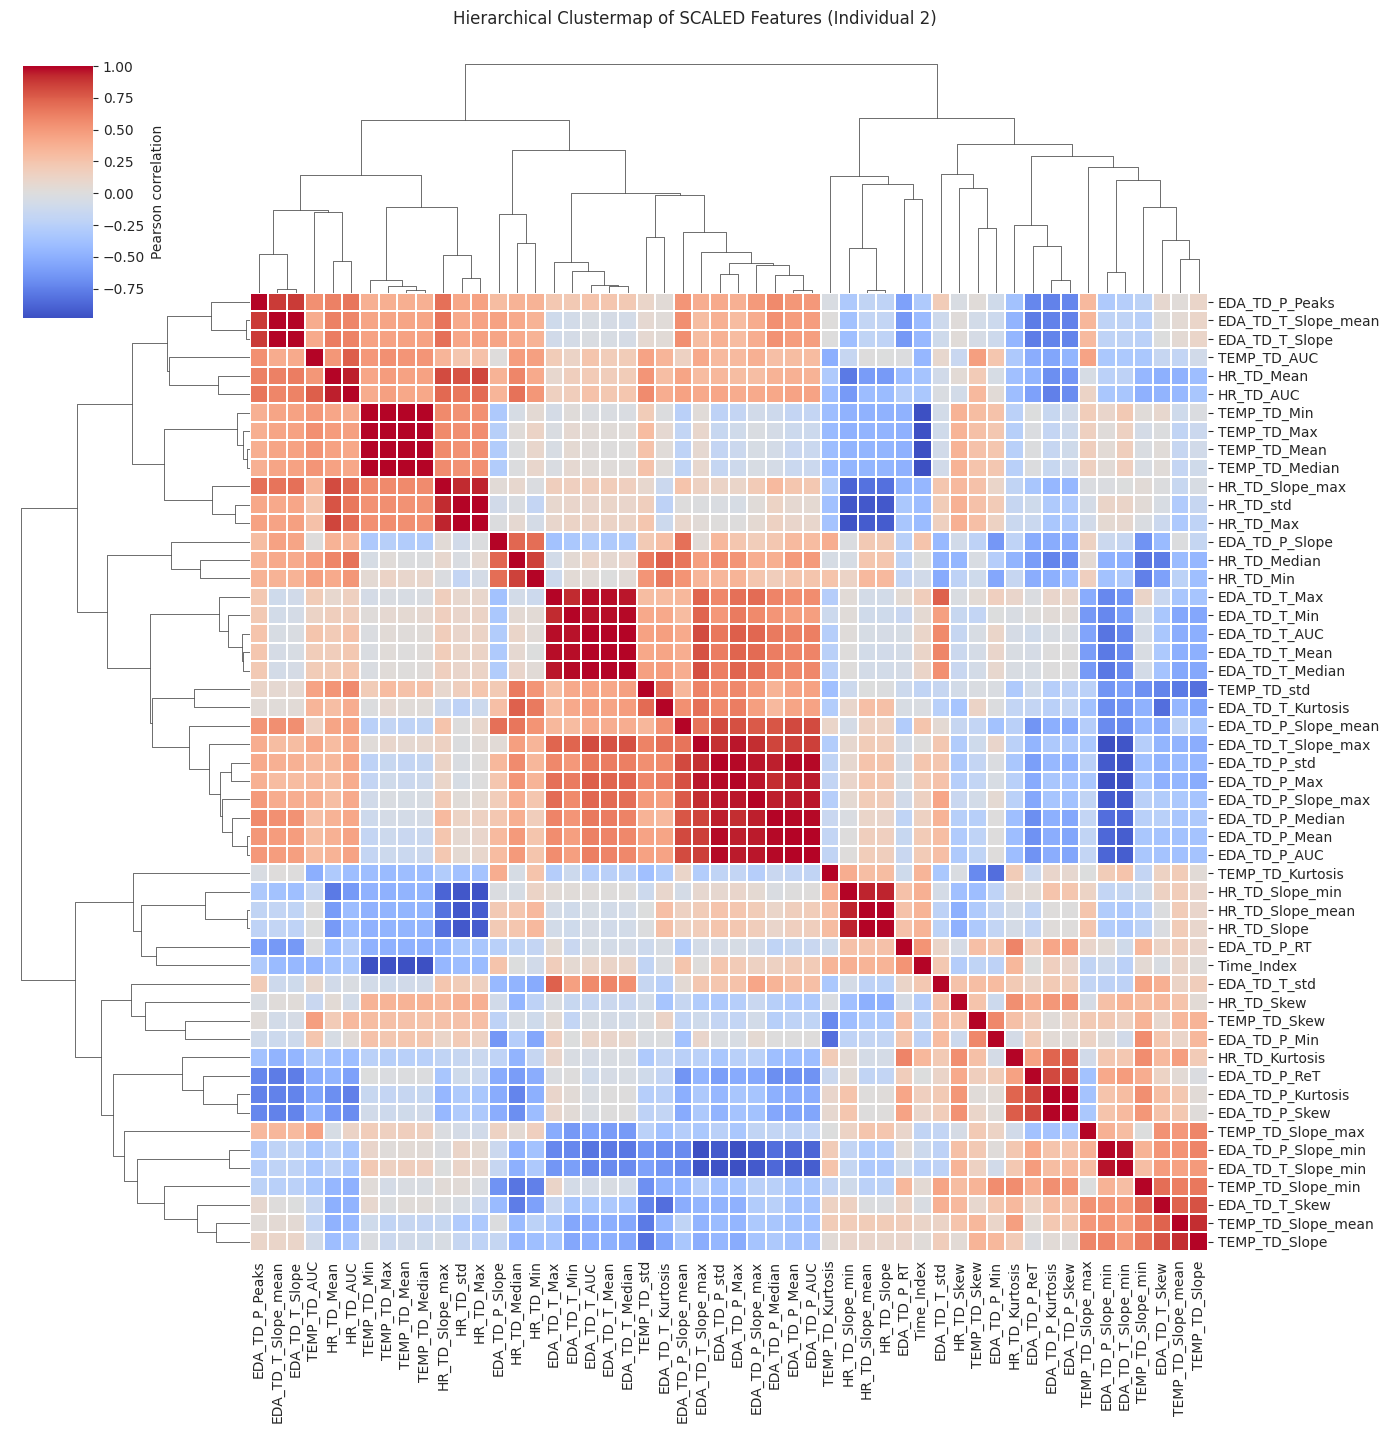

In [106]:
# Same visualization as above, but for Individual 2 (using scaled data)
import matplotlib.pyplot as plt
import seaborn as sns

individual_id = 2

if "pca_input_df" not in globals() or "meta_df" not in globals():
    raise ValueError("Run the preprocessing/scaling cell first so pca_input_df and meta_df exist.")

if "Individual" not in meta_df.columns:
    raise ValueError("meta_df must contain the 'Individual' column.")

if not pca_input_df.index.equals(meta_df.index):
    raise ValueError("pca_input_df and meta_df indices do not match. Re-run preprocessing cell.")

ind_mask = meta_df["Individual"] == individual_id
numeric_ind_df = pca_input_df.loc[ind_mask].copy()

if numeric_ind_df.empty:
    raise ValueError(f"No rows found for Individual={individual_id}.")

non_constant_cols = numeric_ind_df.columns[numeric_ind_df.std(ddof=0) > 0]
numeric_ind_df = numeric_ind_df[non_constant_cols]

if numeric_ind_df.shape[1] < 2:
    print("Not enough varying scaled features to compute a correlation clustermap.")
else:
    corr = numeric_ind_df.corr()
    sns.clustermap(
        corr,
        cmap="coolwarm",
        center=0,
        linewidths=0.2,
        figsize=(14, 14),
        cbar_kws={"label": "Pearson correlation"},
    )
    plt.suptitle(f"Hierarchical Clustermap of SCALED Features (Individual {individual_id})", y=1.02)
    plt.show()

## group

for the group:
- repeat comparisons from individual
    - puzzlers vs instructors

Aggregated stats by Round and Phase (all individuals):
  Round  Phase  group_size  HR_TD_Median_mean  HR_TD_Median_median  HR_TD_Median_std  TEMP_TD_Median_mean  TEMP_TD_Median_median  TEMP_TD_Median_std  EDA_TD_P_Median_mean  EDA_TD_P_Median_median  EDA_TD_P_Median_std  EDA_TD_T_Median_mean  EDA_TD_T_Median_median  EDA_TD_T_Median_std
round_1 phase1          26          77.766154              77.4200          9.844756            32.613077                 32.370            1.590491              0.180194                0.027184             0.431450              4.681311                1.306171             7.177694
round_1 phase2          26          81.229808              79.6250         10.336440            32.757692                 32.490            1.497262              0.595719                0.082689             1.078581              4.977197                1.946112             7.199522
round_1 phase3          26          78.337115              76.2925         10.368407            

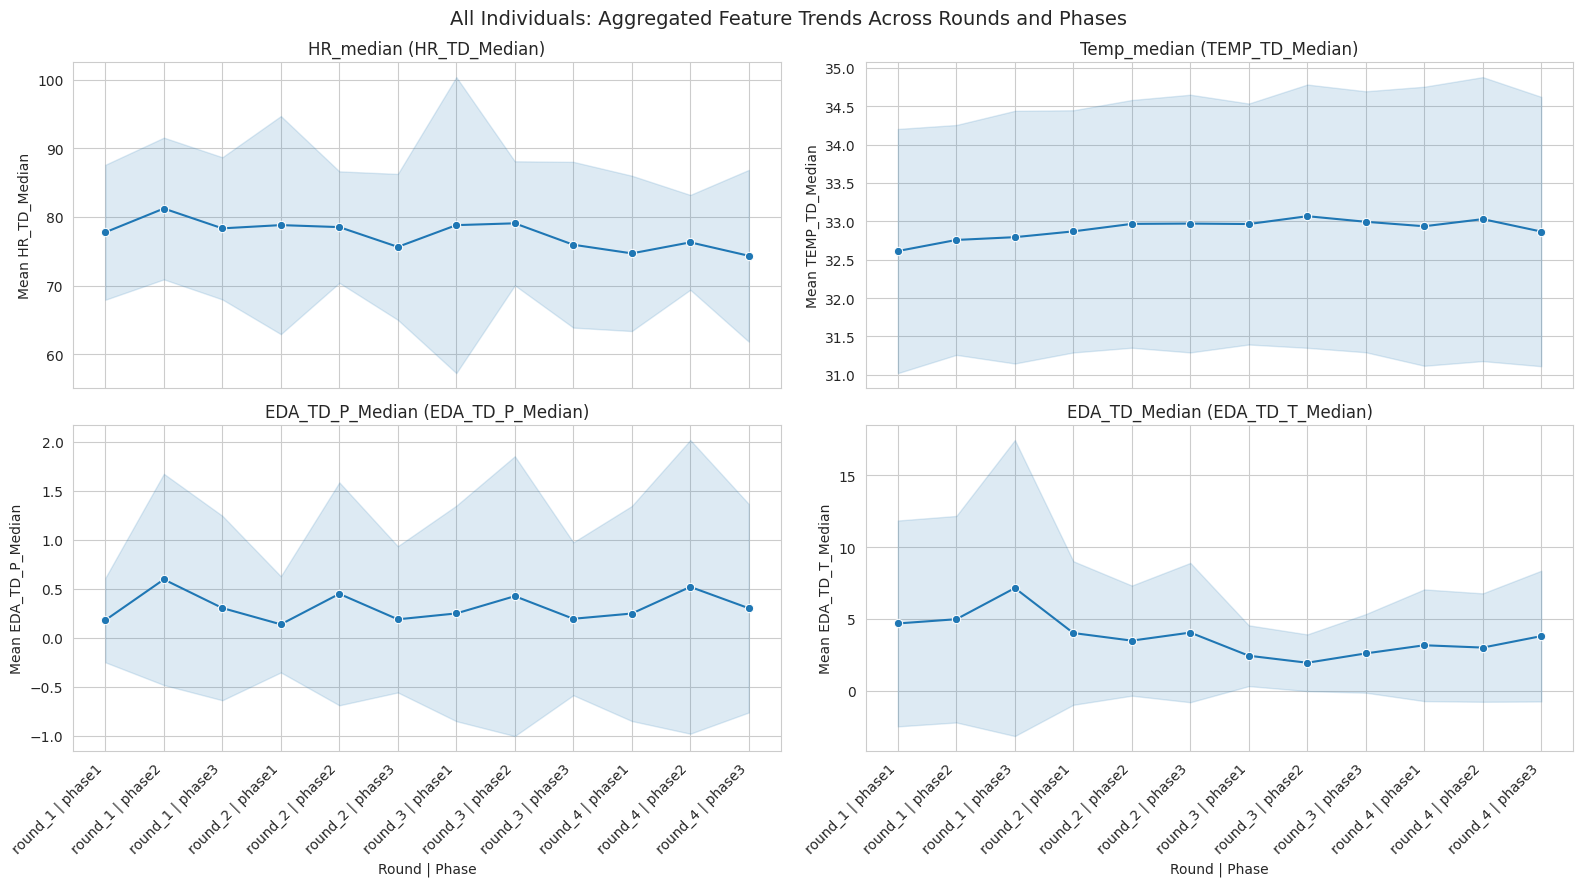

In [114]:
# Group-level comparison (all individuals): HR/TEMP/EDA medians across Round | Phase
import matplotlib.pyplot as plt
import seaborn as sns

# Same feature set style as the individual-comparison cell.
requested_features = {
    "HR_median": ["HR_median", "HR_TD_Median"],
    "Temp_median": ["Temp_median", "TEMP_TD_Median", "Temp_TD_Median"],
    "EDA_TD_P_Median": ["EDA_TD_P_Median"],
    "EDA_TD_Median": ["EDA_TD_Median", "EDA_TD_T_Median"],
}

required_cols = ["Individual", "Round", "Phase"]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# Resolve real column names available in df.
feature_map = {}
missing = []
for label, candidates in requested_features.items():
    match = next((c for c in candidates if c in df.columns), None)
    if match is None:
        missing.append(label)
    else:
        feature_map[label] = match

if not feature_map:
    raise ValueError("None of the requested features were found in df.")

if missing:
    print(f"Missing requested features (skipped): {missing}")

agg_df = df.copy()
agg_df["Round_num"] = agg_df["Round"].astype(str).str.extract(r"(\d+)").astype(float)
agg_df["Phase_num"] = agg_df["Phase"].astype(str).str.extract(r"(\d+)").astype(float)
if agg_df[["Round_num", "Phase_num"]].isna().any().any():
    raise ValueError("Could not parse numeric order from Round/Phase labels.")

agg_df = agg_df.sort_values(["Round_num", "Phase_num", "Individual"])
agg_df["Round_Phase"] = agg_df["Round"].astype(str) + " | " + agg_df["Phase"].astype(str)

x_order = (
    agg_df[["Round_num", "Phase_num", "Round_Phase"]]
    .drop_duplicates()
    .sort_values(["Round_num", "Phase_num"])["Round_Phase"]
    .tolist()
)

# Aggregate mean/median/std per Round+Phase for each selected feature.
group_keys = ["Round", "Phase", "Round_num", "Phase_num", "Round_Phase"]
summary_df = agg_df.groupby(group_keys, as_index=False)[list(feature_map.values())].agg(["mean", "median", "std"] )
summary_df.columns = ["_".join([c for c in col if c]).strip("_") for col in summary_df.columns]

# Add one shared group size column for each Round+Phase bin.
group_size_df = (
    agg_df.groupby(group_keys, as_index=False)
    .size()
    .rename(columns={"size": "group_size"})
)
summary_df = summary_df.merge(group_size_df, on=group_keys, how="left")
summary_df = summary_df.sort_values(["Round_num", "Phase_num"] )

preview_cols = ["Round", "Phase", "group_size"]
for col_name in feature_map.values():
    preview_cols.extend([f"{col_name}_mean", f"{col_name}_median", f"{col_name}_std"] )

print("Aggregated stats by Round and Phase (all individuals):")
print(summary_df[preview_cols].to_string(index=False))

sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex=True)
axes = axes.flatten()

for ax, (label, col_name) in zip(axes, feature_map.items()):
    sns.lineplot(
        data=summary_df,
        x="Round_Phase",
        y=f"{col_name}_mean",
        marker="o",
        sort=False,
        ax=ax,
        color="#1f77b4",
    )
    ax.fill_between(
        range(len(summary_df)),
        (summary_df[f"{col_name}_mean"] - summary_df[f"{col_name}_std"]).values,
        (summary_df[f"{col_name}_mean"] + summary_df[f"{col_name}_std"]).values,
        alpha=0.15,
        color="#1f77b4",
    )
    ax.set_title(f"{label} ({col_name})")
    ax.set_xlabel("Round | Phase")
    ax.set_ylabel(f"Mean {col_name}")
    ax.set_xticks(range(len(x_order)))
    ax.set_xticklabels(x_order, rotation=45, ha="right")

for ax in axes[len(feature_map):]:
    ax.set_visible(False)

plt.suptitle("All Individuals: Aggregated Feature Trends Across Rounds and Phases", fontsize=14)
plt.tight_layout()
plt.show()

Aggregated EDA dynamic stats by Round and Phase (all individuals):
  Round  Phase  EDA_TD_P_Peaks_mean  EDA_TD_P_Peaks_median  EDA_TD_P_Peaks_std  EDA_TD_P_Peaks_count  EDA_TD_P_RT_mean  EDA_TD_P_RT_median  EDA_TD_P_RT_std  EDA_TD_P_RT_count  EDA_TD_P_ReT_mean  EDA_TD_P_ReT_median  EDA_TD_P_ReT_std  EDA_TD_P_ReT_count
round_1 phase1            24.115385                   21.0           10.493148                    26          2.070274            1.975000         0.421936                 26           2.122606             1.944170          0.774816                  26
round_1 phase2            37.230769                   40.0           11.279389                    26          1.796982            1.780392         0.245600                 26           1.742565             1.669271          0.491468                  26
round_1 phase3            21.384615                   21.0            8.630536                    26          1.961749            1.928679         0.355464                 26

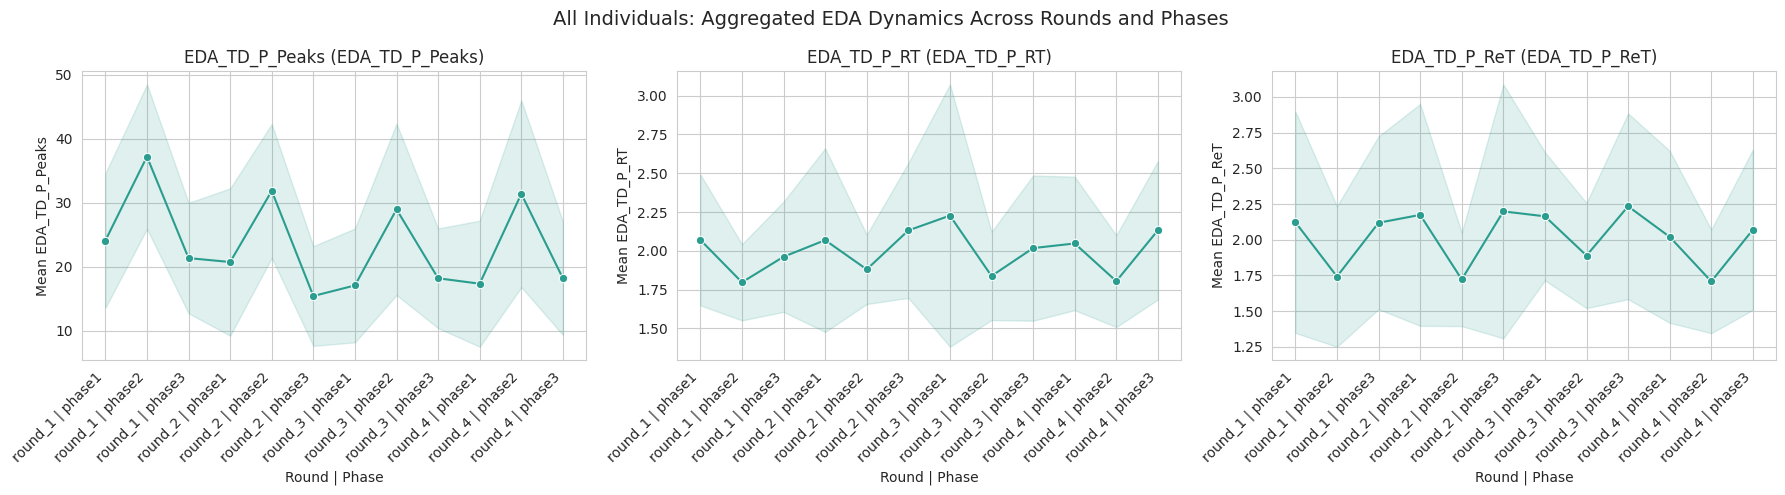

In [113]:
# Comparing EDA dynamics features across all individuals by Round and Phase
import matplotlib.pyplot as plt
import seaborn as sns

eda_dynamic_features = {
    "EDA_TD_P_Peaks": ["EDA_TD_P_Peaks"],
    "EDA_TD_P_RT": ["EDA_TD_P_RT"],
    "EDA_TD_P_ReT": ["EDA_TD_P_ReT"],
}

required_cols = ["Individual", "Round", "Phase"]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# Resolve available EDA dynamic columns in df.
feature_map_eda = {}
missing_eda = []
for label, candidates in eda_dynamic_features.items():
    match = next((c for c in candidates if c in df.columns), None)
    if match is None:
        missing_eda.append(label)
    else:
        feature_map_eda[label] = match

if not feature_map_eda:
    raise ValueError("None of the requested EDA dynamic features were found in df.")

if missing_eda:
    print(f"Missing requested EDA dynamic features (skipped): {missing_eda}")

agg_eda_df = df.copy()
agg_eda_df["Round_num"] = agg_eda_df["Round"].astype(str).str.extract(r"(\d+)").astype(float)
agg_eda_df["Phase_num"] = agg_eda_df["Phase"].astype(str).str.extract(r"(\d+)").astype(float)
if agg_eda_df[["Round_num", "Phase_num"]].isna().any().any():
    raise ValueError("Could not parse numeric order from Round/Phase labels.")

agg_eda_df = agg_eda_df.sort_values(["Round_num", "Phase_num", "Individual"])
agg_eda_df["Round_Phase"] = agg_eda_df["Round"].astype(str) + " | " + agg_eda_df["Phase"].astype(str)

x_order_eda_group = (
    agg_eda_df[["Round_num", "Phase_num", "Round_Phase"]]
    .drop_duplicates()
    .sort_values(["Round_num", "Phase_num"])["Round_Phase"]
    .tolist()
)

# Aggregate per Round+Phase for each selected EDA dynamic feature.
group_keys = ["Round", "Phase", "Round_num", "Phase_num", "Round_Phase"]
summary_eda_df = agg_eda_df.groupby(group_keys, as_index=False)[list(feature_map_eda.values())].agg(["mean", "median", "std", "count"])
summary_eda_df.columns = ["_".join([c for c in col if c]).strip("_") for col in summary_eda_df.columns]
summary_eda_df = summary_eda_df.sort_values(["Round_num", "Phase_num"])

preview_cols = ["Round", "Phase"]
for col_name in feature_map_eda.values():
    preview_cols.extend([f"{col_name}_mean", f"{col_name}_median", f"{col_name}_std", f"{col_name}_count"])

print("Aggregated EDA dynamic stats by Round and Phase (all individuals):")
print(summary_eda_df[preview_cols].to_string(index=False))

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

for ax, (label, col_name) in zip(axes, feature_map_eda.items()):
    sns.lineplot(
        data=summary_eda_df,
        x="Round_Phase",
        y=f"{col_name}_mean",
        marker="o",
        sort=False,
        ax=ax,
        color="#2a9d8f",
    )
    ax.fill_between(
        range(len(summary_eda_df)),
        (summary_eda_df[f"{col_name}_mean"] - summary_eda_df[f"{col_name}_std"]).values,
        (summary_eda_df[f"{col_name}_mean"] + summary_eda_df[f"{col_name}_std"]).values,
        alpha=0.15,
        color="#2a9d8f",
    )
    ax.set_title(f"{label} ({col_name})")
    ax.set_xlabel("Round | Phase")
    ax.set_ylabel(f"Mean {col_name}")
    ax.set_xticks(range(len(x_order_eda_group)))
    ax.set_xticklabels(x_order_eda_group, rotation=45, ha="right")

plt.suptitle("All Individuals: Aggregated EDA Dynamics Across Rounds and Phases", fontsize=14)
plt.tight_layout()
plt.show()

Resolved columns:
- EDA_P_slope: EDA_TD_P_Slope
- EDA_T_slope: EDA_TD_T_Slope
- EDA_P_median: EDA_TD_P_Median
- EDA_T_median: EDA_TD_T_Median

Group summary by Round and Phase (means only):
  Round  Phase  group_size  EDA_P_slope_mean  EDA_T_slope_mean  EDA_P_median_mean  EDA_T_median_mean
round_1 phase1          26          0.000232          0.000450           0.180194           4.681311
round_1 phase2          26          0.000970          0.000527           0.595719           4.977197
round_1 phase3          26          0.000256         -0.000388           0.303484           7.149546
round_2 phase1          26          0.000447         -0.000918           0.136821           4.013508
round_2 phase2          26          0.000397          0.000271           0.448320           3.483446
round_2 phase3          26         -0.000005         -0.000400           0.188182           4.045077
round_3 phase1          26          0.000314         -0.000481           0.248466           2.430645
ro

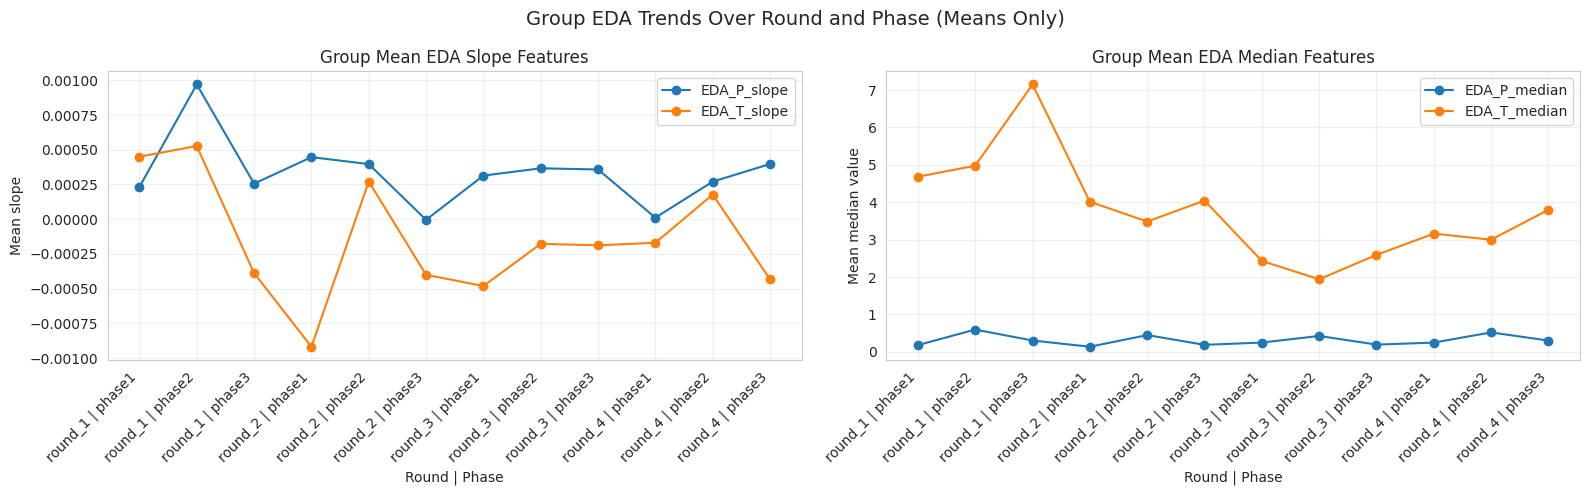

In [122]:
# Group trends over Round | Phase for EDA_P_slope, EDA_T_slope, EDA_P_median, and EDA_T_median
import matplotlib.pyplot as plt
import seaborn as sns

required_cols = ["Individual", "Round", "Phase"]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

def resolve_column(explicit_candidates, include_tokens, exclude_tokens=None):
    for c in explicit_candidates:
        if c in df.columns:
            return c

    exclude_tokens = exclude_tokens or []
    dynamic = []
    for c in df.columns:
        cl = c.lower()
        if all(tok in cl for tok in include_tokens) and not any(tok in cl for tok in exclude_tokens):
            dynamic.append(c)

    if dynamic:
        return sorted(dynamic)[0]
    return None

# Resolve slope features
p_slope_col = resolve_column(
    ["EDA_TD_P_Slope", "EDA_P_Slope", "EDA_TD_P_slope", "EDA_P_slope"],
    include_tokens=["eda", "slope", "p"],
    exclude_tokens=["ret", "rt"],
)
t_slope_col = resolve_column(
    ["EDA_TD_T_Slope", "EDA_T_Slope", "EDA_TD_T_slope", "EDA_T_slope"],
    include_tokens=["eda", "slope", "t"],
    exclude_tokens=["ret", "rt"],
)

# Resolve median features
p_median_col = resolve_column(
    ["EDA_TD_P_Median", "EDA_P_Median", "EDA_TD_P_median", "EDA_P_median"],
    include_tokens=["eda", "median", "p"],
    exclude_tokens=["peak", "rt", "ret", "slope"],
)
t_median_col = resolve_column(
    ["EDA_TD_T_Median", "EDA_TD_Median", "EDA_T_Median", "EDA_T_median"],
    include_tokens=["eda", "median", "t"],
    exclude_tokens=["p", "peak", "rt", "ret", "slope"],
)

resolved = {
    "EDA_P_slope": p_slope_col,
    "EDA_T_slope": t_slope_col,
    "EDA_P_median": p_median_col,
    "EDA_T_median": t_median_col,
}

if any(v is None for v in resolved.values()):
    missing = {k: v for k, v in resolved.items() if v is None}
    raise ValueError(
        f"Could not resolve all requested EDA features. Missing: {missing}. "
        f"Available EDA columns: {[c for c in df.columns if 'eda' in c.lower()]}"
    )

work_df = df.copy()
work_df["Round_num"] = work_df["Round"].astype(str).str.extract(r"(\d+)").astype(float)
work_df["Phase_num"] = work_df["Phase"].astype(str).str.extract(r"(\d+)").astype(float)
if work_df[["Round_num", "Phase_num"]].isna().any().any():
    raise ValueError("Could not parse Round/Phase labels for ordering.")

work_df = work_df.sort_values(["Round_num", "Phase_num", "Individual"])
work_df["Round_Phase"] = work_df["Round"].astype(str) + " | " + work_df["Phase"].astype(str)

x_order = (
    work_df[["Round_num", "Phase_num", "Round_Phase"]]
    .drop_duplicates()
    .sort_values(["Round_num", "Phase_num"])["Round_Phase"]
    .tolist()
)

# Aggregate only mean trends requested by Round+Phase.
grouped = (
    work_df.groupby(["Round", "Phase", "Round_num", "Phase_num", "Round_Phase"], as_index=False)
    .agg(
        group_size=("Individual", "size"),
        EDA_P_slope_mean=(p_slope_col, "mean"),
        EDA_T_slope_mean=(t_slope_col, "mean"),
        EDA_P_median_mean=(p_median_col, "mean"),
        EDA_T_median_mean=(t_median_col, "mean"),
    )
    .sort_values(["Round_num", "Phase_num"])
)

print("Resolved columns:")
for label, col in resolved.items():
    print(f"- {label}: {col}")

print("\nGroup summary by Round and Phase (means only):")
print(grouped[[
    "Round",
    "Phase",
    "group_size",
    "EDA_P_slope_mean",
    "EDA_T_slope_mean",
    "EDA_P_median_mean",
    "EDA_T_median_mean",
 ]].to_string(index=False))

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)

# Slope means only
axes[0].plot(grouped["Round_Phase"], grouped["EDA_P_slope_mean"], marker="o", label="EDA_P_slope")
axes[0].plot(grouped["Round_Phase"], grouped["EDA_T_slope_mean"], marker="o", label="EDA_T_slope")
axes[0].set_title("Group Mean EDA Slope Features")
axes[0].set_xlabel("Round | Phase")
axes[0].set_ylabel("Mean slope")
axes[0].set_xticks(range(len(x_order)))
axes[0].set_xticklabels(x_order, rotation=45, ha="right")
axes[0].legend()

# Median means only
axes[1].plot(grouped["Round_Phase"], grouped["EDA_P_median_mean"], marker="o", label="EDA_P_median")
axes[1].plot(grouped["Round_Phase"], grouped["EDA_T_median_mean"], marker="o", label="EDA_T_median")
axes[1].set_title("Group Mean EDA Median Features")
axes[1].set_xlabel("Round | Phase")
axes[1].set_ylabel("Mean median value")
axes[1].set_xticks(range(len(x_order)))
axes[1].set_xticklabels(x_order, rotation=45, ha="right")
axes[1].legend()

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.suptitle("Group EDA Trends Over Round and Phase (Means Only)", fontsize=14)
plt.tight_layout()
plt.show()

# use alberts work as preparation


Subspace Representation (The Representation Challenge)

- compress the features into a (hopefully) meaningful 2D or 3D map.

    1. Baseline PCA: Run PCA on the full scaled dataset.

    2. Determine Dimensions: Use a Scree Plot and the Cumulative Explained Variance plot.

        Goal: Find the "Elbow" and aim to capture 70-80% of total variance.

    3. The "double-View" Visualization: Create 2D scatter plots (PC1​ vs. PC2​) and color-code them by:

        Phase: Does the space separate "Rest" from "Stress"?

        Role: Is there a distinct "Instructor" vs "Solver" region?

    4. 3 dim viz?


Slide 20: 
Make a scree plot - compare eigenvalues to those obtained from randomized data (with same total
variance)

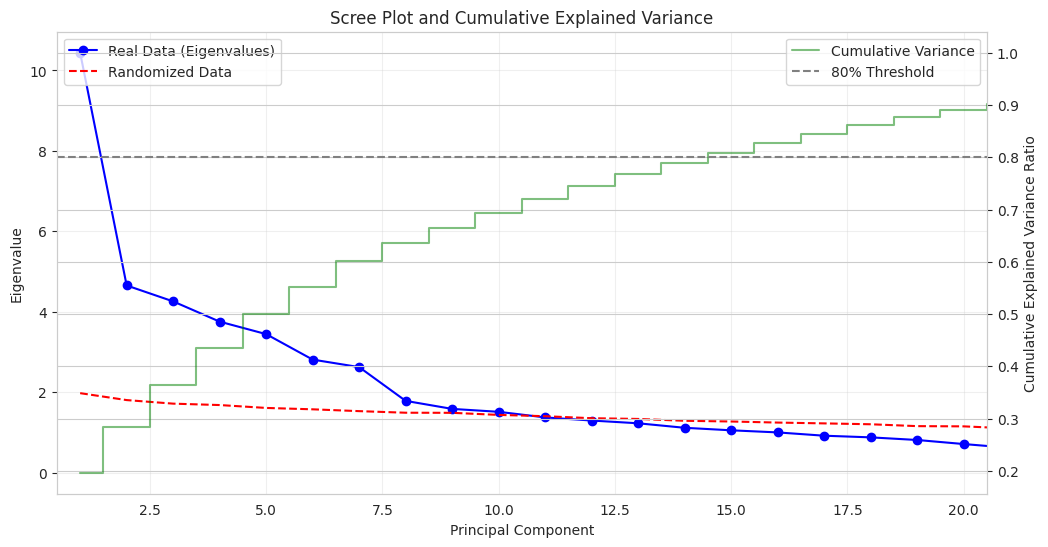

Variance captured by PC1: 19.63%
Variance captured by PC2: 8.76%
Total variance in first 3 PCs: 36.40%

'viz_df' is ready for PC1 vs PC2 visualization.


In [126]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Baseline PCA on the full scaled dataset
pca = PCA()
pca_transformed = pca.fit_transform(pca_input_df)

# 2. Parallel Analysis: Randomized Data Comparison
shuffled_df = pca_input_df.copy()
for column in shuffled_df.columns:
    # permutation returns a shuffled COPY, avoiding the read-only error
    shuffled_df[column] = np.random.permutation(shuffled_df[column].values)

pca_random = PCA()
pca_random.fit(shuffled_df)
# Get eigenvalues (explained_variance_)
eigenvalues = pca.explained_variance_
random_eigenvalues = pca_random.explained_variance_

# 3. Visualization: Scree Plot & Cumulative Explained Variance
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Eigenvalues (Scree Plot)
ax1.plot(range(1, len(eigenvalues) + 1), eigenvalues, 'o-', label='Real Data (Eigenvalues)', color='blue')
ax1.plot(range(1, len(random_eigenvalues) + 1), random_eigenvalues, '--', label='Randomized Data', color='red')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Eigenvalue')
ax1.set_title('Scree Plot and Cumulative Explained Variance')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Plot Cumulative Explained Variance on a second y-axis
ax2 = ax1.twinx()
cum_variance = np.cumsum(pca.explained_variance_ratio_)
ax2.step(range(1, len(cum_variance) + 1), cum_variance, where='mid', label='Cumulative Variance', color='green', alpha=0.5)
ax2.axhline(y=0.8, color='grey', linestyle='--', label='80% Threshold')
ax2.set_ylabel('Cumulative Explained Variance Ratio')
ax2.legend(loc='upper right')

# Zoom in on the first 20 components for clarity
ax1.set_xlim(0.5, 20.5)
plt.show()

# 4. Results Processing
# Determine dimensions where Real > Random and check 70-80% goal
print(f"Variance captured by PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"Variance captured by PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"Total variance in first 3 PCs: {cum_variance[2]*100:.2f}%")

# 5. Transform and Stitch back to meta_df
pca_cols = [f'PC{i+1}' for i in range(pca_transformed.shape[1])]
df_pca_results = pd.DataFrame(pca_transformed, columns=pca_cols, index=pca_input_df.index)
viz_df = pd.concat([meta_df, df_pca_results], axis=1)

print("\n'viz_df' is ready for PC1 vs PC2 visualization.")

PC1 Eigenvalue of over 10! -> almost20% of variance
readline crossed/met after about PC8 -> 65% of the variance explained
though after PC 7 there is another "elbow" -> explains 60% of the variance

not going to use the 80% threshold -> 

Based on the Parallel Analysis, the first 10 Principal Components reside above the noise floor. However, a distinct 'elbow' is observed after PC 7. Therefore, 7 components were retained as the optimal subspace for representation, capturing approximately [X]% of the total variance, while the first three were selected for 3D visualization due to their high eigenvalues."

# Explainability & Feature Importance

Find out why the points are where they are.

    (Apply Sparse PCA: Force the 100 features down to the 10 most "essential" ones.
    Question to answer: Do the same features (like EDA peaks) drive the morning and evening models equally?)

    Loading Analysis: Extract the weights for PC1​ and PC2​

    Task: Create a bar chart of the top 10 features